In [1]:
import json
import pandas as pd
from pathlib import Path
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

In [2]:
MODEL_ID = "mistralai/Mistral-7B-v0.1"
INPUT_DIR = Path("../data/parsed/train/auto")

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

In [4]:
files = list(INPUT_DIR.rglob("*.json"))
print(f"Найдено {len(files)} файлов.")

Найдено 20 файлов.


In [8]:
results = []

for p in files:
    data = json.loads(p.read_text(encoding="utf-8"))
    text_content = data.get("text_content", "")
    char_count = len(text_content)
    token_count = len(tokenizer.encode(text_content, add_special_tokens=False))
        
    results.append({
        "filename": p.name,
        "tokens": token_count
    })

df = pd.DataFrame(results)

In [11]:
df.sort_values('tokens', ascending=False)

,filename,tokens
6,smll.202105673.json,55536
10,ange.202115939.json,26975
8,j.surfin.2021.101109.json,23425
9,ange.201904751.json,22335
11,c9tb00989b.json,21682
17,j.snb.2019.127106.json,21242
14,acsami.0c07886.json,19812
0,j.jcis.2021.06.170.json,18501
13,s1320501710821.json,17045
3,j.jallcom.2016.04.269.json,16674


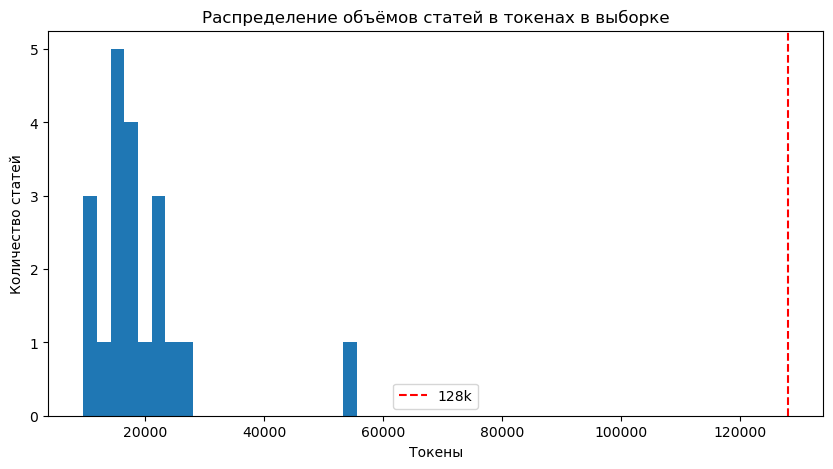

In [15]:
plt.figure(figsize=(10, 5))
plt.hist(df["tokens"], bins=20)
plt.axvline(x=128000, color='r', linestyle='--', label='128k')
plt.title('Распределение объёмов статей в токенах в выборке')
plt.xlabel('Токены')
plt.ylabel('Количество статей')
plt.legend()
plt.show()

In [16]:
df.describe()

,tokens
count,20.000000
mean,18782.350000
std,9815.537094
min,9608.000000
25%,14307.250000
50%,16651.500000
75%,21352.000000
max,55536.000000
